# Exploratory Data Analysis (EDA) on Zomato Dataset

In [1]:
#importing libraries
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
#importing dataset
df=pd.read_csv("Zomato dataset.csv")
df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining


In [8]:
# Data cleaning
# 1) converting the data types of column (rate)

def handleRate(value):
    value=str(value).split('/')
    value=value[0];
    return float (value)
df['rate']=df['rate'].apply(handleRate)

In [10]:
df.head()


,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [15]:
# 2) identifying and handling Missing values
df.info()
df.rename(columns={"listed_in(type)":"Restaurant_Category", "votes":"Total_votes", "name":"Restaurant_Name","rate":"Rating"}, inplace=True)
df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Restaurant_Name              148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   Rating                       148 non-null    float64
 4   Total_votes                  148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   Restaurant_Category          148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


,Restaurant_Name,online_order,book_table,Rating,Total_votes,approx_cost(for two people),Restaurant_Category
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet
5,Timepass Dinner,Yes,No,3.8,286,600,Buffet
6,Rosewood International Hotel - Bar & Restaurant,No,No,3.6,8,800,Buffet
7,Onesta,Yes,Yes,4.6,2556,600,Cafes
8,Penthouse Cafe,Yes,No,4.0,324,700,other
9,Smacznego,Yes,No,4.2,504,550,Cafes


# Q1) What type of restaurant do the majority of customers order from?

C:\Users\adrai\AppData\Local\Temp\ipykernel_25060\3531860476.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Restaurant_Category'],palette='viridis')


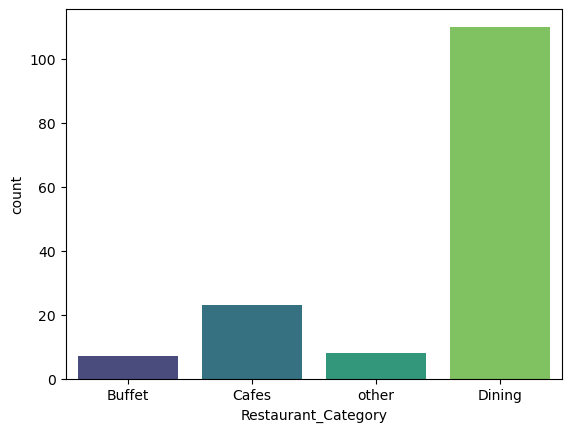

In [37]:
sns.countplot(x=df['Restaurant_Category'],palette='viridis')
plt.xlabel("Restaurant_Category")
plt.show()

The dataset shows that the Dining category has the highest number of restaurants.

# Q2) How many votes has each type of restaurant received from customers?

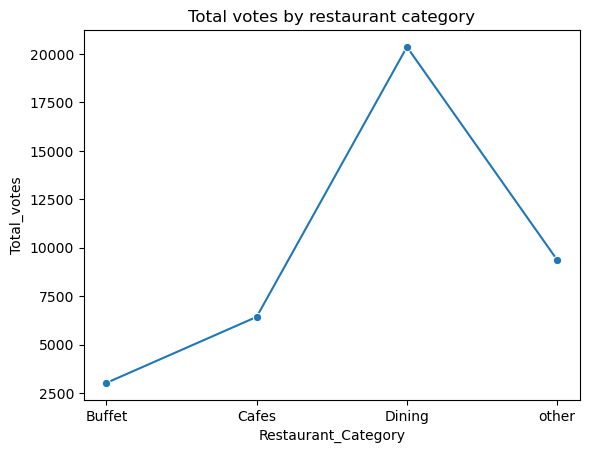

In [33]:
category_votes=df.groupby('Restaurant_Category')['Total_votes'].sum()
result=pd.DataFrame({'Total_votes':category_votes})
sns.lineplot(x='Restaurant_Category',y='Total_votes',data=result,marker='o')
plt.title("Total votes by restaurant category")
plt.show()

Dining restaurants have received the maximum number of votes.

# Q3) What are the ratings that the majority of restaurants have received?

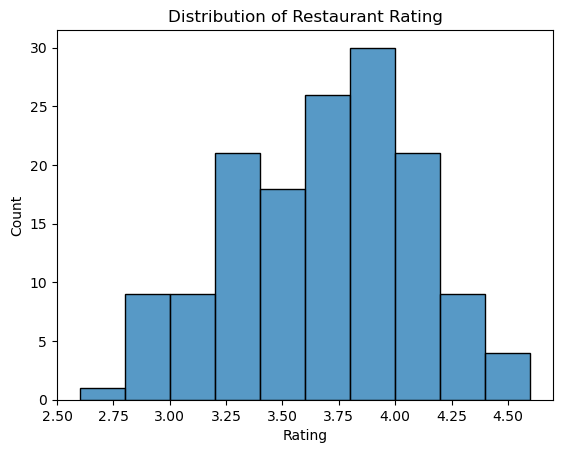

In [40]:
sns.histplot(df['Rating'],bins=10)
plt.title("Distribution of Restaurant Rating")
plt.show()

Conclusion: Most restaurants have a rating between 3.5 and 4.5.

# Q4) Zomato has observed that most couples order online. What is their average spending on each order?

# Average order spending by couples

In [44]:
df.head(10)

,Restaurant_Name,online_order,book_table,Rating,Total_votes,approx_cost(for two people),Restaurant_Category
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet
5,Timepass Dinner,Yes,No,3.8,286,600,Buffet
6,Rosewood International Hotel - Bar & Restaurant,No,No,3.6,8,800,Buffet
7,Onesta,Yes,Yes,4.6,2556,600,Cafes
8,Penthouse Cafe,Yes,No,4.0,324,700,other
9,Smacznego,Yes,No,4.2,504,550,Cafes


C:\Users\adrai\AppData\Local\Temp\ipykernel_25060\3851076132.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=couple_data,palette='Set2')


<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

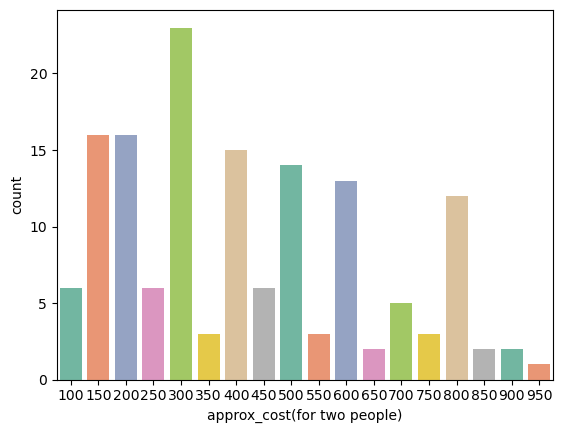

In [49]:
couple_data=df['approx_cost(for two people)']
sns.countplot(x=couple_data,palette='Set2')

The most frequent spending amount for a couple is 300 rupees.

# Q5) Which mode (online or offline) has received the highest rating?

In [50]:
df.head()

,Restaurant_Name,online_order,book_table,Rating,Total_votes,approx_cost(for two people),Restaurant_Category
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


C:\Users\adrai\AppData\Local\Temp\ipykernel_25060\2018066206.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='online_order', y='Rating',data=df,palette='Set2')


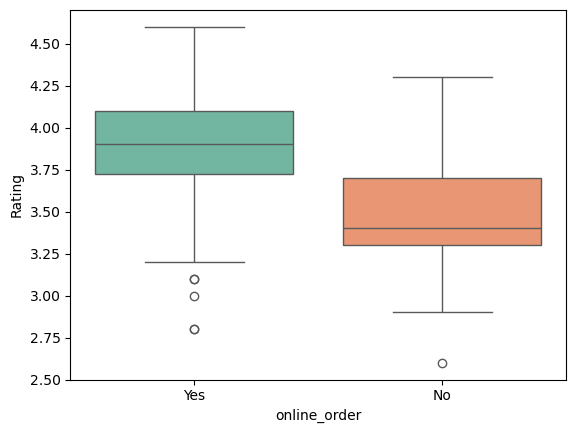

<Figure size 600x600 with 0 Axes>

In [54]:
sns.boxplot(x='online_order', y='Rating',data=df,palette='Set2')
plt.figure(figsize=(6,6))
plt.show()

Conclusion: The online ordering mode has received the highest average rating.

# Q6) Which types of restaurants receive more offline orders, so that Zomato can provide better offers?

Order mode vs. restaurant types

In [57]:
df.head()

,Restaurant_Name,online_order,book_table,Rating,Total_votes,approx_cost(for two people),Restaurant_Category
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


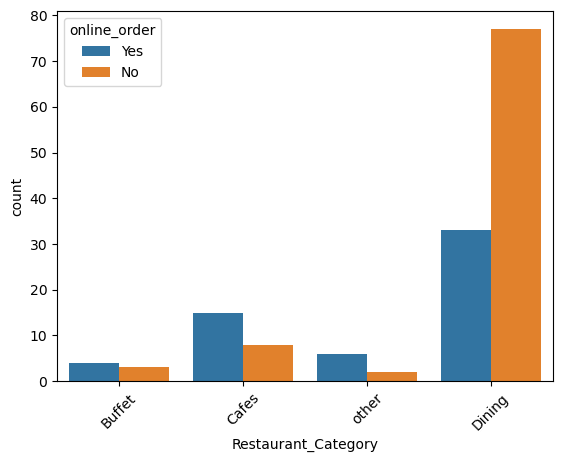

In [56]:
sns.countplot(x='Restaurant_Category', hue='online_order', data=df)
plt.xticks(rotation=45)
plt.show()

Conclusion: Dining restaurants have the highest number of offline orders.